# Buisness Problem

- The company wants to understand different types of customers.
- Current marketing treats all customers similarly.
- Customer segmentation enables personalized marketing.
- It helps improve retention and increase revenue.
- We will use suitable clustering Algorithm to group similar customers.

# Dataset Overview

In [1]:
import pandas as pd

data = pd.read_csv("online_retail_II.csv")
print("Data first 5 rows: \n",data.head())
print("-------------------------------------------------------")
print("-------------------------------------------------------")
print("\n\nData Shape: ", data.shape)
print("-------------------------------------------------------")
print("-------------------------------------------------------")
print("\n\nCheck for null values: \n", data.isna().sum())
print("-------------------------------------------------------")
print("-------------------------------------------------------")
print("\n\nData Info:")
data.info()
print("\n")

Data first 5 rows: 
   Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
-------------------------------------------------------
-------------------------------------------------------


Data Shape:  (1067371, 8)
----------------------------------------------------

# Data Quality Assessment

In [2]:
# checking missing percentage
print("Missing percentage per column: ")
missing_percent = (data.isnull().sum() / len(data))* 100
print(missing_percent)


# check how many cancelled transactions 
cancelled_count = data["Invoice"].str.startswith("C", na=False).sum()
print("\nCancelled transactions: ", cancelled_count)
print("\n")
print("Cancelled first 5 Transaction: ") 
print(data[data["Invoice"].str.startswith("C", na=False)].head())
print("\n")


# negative quantities other than cancelled transaction
print("Not cancelled transactions with negative quantities: ")
print(data[(data["Quantity"] <0) & (~data["Invoice"].str.startswith("C", na=False))])
print("\n")
print("Invalid Transaction's price: ")
print(data[(data["Quantity"] <0) & (~data["Invoice"].str.startswith("C", na=False))]["Price"].value_counts())
print("\n")


# check for duplicates
duplicate_percent = (data.duplicated().sum() / len(data))*100
print(f"Duplicate Percent: {duplicate_percent:.2f}%")
print("\n")
duplicates = data[data.duplicated(keep=False)]
print("Number of duplicate transaction that are cancelled: ") 
print(duplicates["Invoice"].str.startswith("C", na=False).value_counts())
print("\n")
print("Duplicate Transaction records: ")
print(duplicates.sort_values(["Invoice", "StockCode"]).head(20))
print("\n")

# Transactions with negative price
negative_price=data[data["Price"] <0]
print("Negative Price rows: ")
print(negative_price.head())
print("\n")

Missing percentage per column: 
Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64

Cancelled transactions:  19494


Cancelled first 5 Transaction: 
     Invoice StockCode                    Description  Quantity  \
178  C489449     22087       PAPER BUNTING WHITE LACE       -12   
179  C489449    85206A   CREAM FELT EASTER EGG BASKET        -6   
180  C489449     21895  POTTING SHED SOW 'N' GROW SET        -4   
181  C489449     21896             POTTING SHED TWINE        -6   
182  C489449     22083     PAPER CHAIN KIT RETRO SPOT       -12   

             InvoiceDate  Price  Customer ID    Country  
178  2009-12-01 10:33:00   2.95      16321.0  Australia  
179  2009-12-01 10:33:00   1.65      16321.0  Australia  
180  2009-12-01 10:33:00   4.25      16321.0  Australia  
181  2009-12-01 10:33:00   2.10      16321.0  Austra

### Missing Value Analysis
- Description has only 0.41% missing values.
- Customer ID has 22.77% missing values.
- Customer ID is essential for customer-level segmentation.
- Rows with missing Customer ID will be removed.
- Description will be dropped since it is not required for customer segmentation.

### Invoice Analysis
- The dataset contains 19,494 cancelled transaction.
- Cancelled invoices identified by an Invoice number starting with "C".
- These transactions have negative quatities, indicating product returns or refunds.
- Since customer segmentation should be based on actual purchases, cancelled transactions will be removed from the dataset.

### Invalid Transaction Analysis
- 3,457 records have negative quantities without a cancelled invoice.
- All these records have a price of 0 and missing Customer IDs.
- Descriptions such as "missing", "lost", "smashed", and "check" indicate inventory adjustments rather than customer purchase.
- Since customer segmentation should be based on actual purchases, these columns will be removed.

### Duplicate Analysis
- The dataset contains 3.22% duplicate records.
- The duplicate records have dentical values across all columns.
- These records are likely duplicate entries created during data collection.
- Exact duplicate records will be removed to avoid double-counting transactiopns.

### Negative Price Analysis
- Only 5 records have negative prices.
- These records are marked as "Adjust bad debt" with StockCode "B".
- They have missing Customer IDs and do not represent product purchases.
- These accounting adjustment records will be removed before customer segmentation.

# Data Cleaning

In [3]:
from preprocessing import clean_data

data = clean_data(data)

### Data Cleaning Summary

In [4]:
print("Shape of the dataset: ", data.shape)
print("\nData Info: ")
data.info()
print("\nNull values: \n",data.isnull().sum())
print("\nDuplicated values: ",data.duplicated().sum())

Shape of the dataset:  (779493, 7)

Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779493 entries, 0 to 779492
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779493 non-null  object        
 1   StockCode    779493 non-null  object        
 2   Quantity     779493 non-null  int64         
 3   InvoiceDate  779493 non-null  datetime64[ns]
 4   Price        779493 non-null  float64       
 5   Customer ID  779493 non-null  float64       
 6   Country      779493 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 41.6+ MB

Null values: 
 Invoice        0
StockCode      0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Duplicated values:  0


# Exploratory Data Analysis

## Univariate Analysis

- #### Customer ID Analysis

Unique Customer ID:  5881


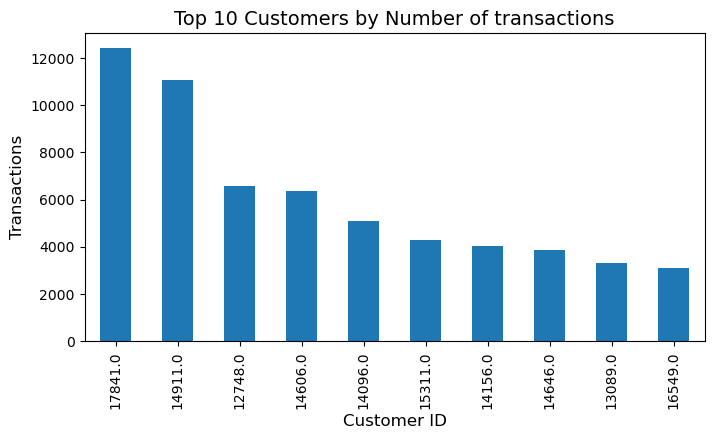

In [5]:
import matplotlib.pyplot as plt

# Total unique customers
print("Unique Customer ID: ", data["Customer ID"].nunique())

# Top 10 customers by number of transactions
data["Customer ID"].value_counts().head(10).plot(kind="bar", figsize=(8,4))
plt.title("Top 10 Customers by Number of transactions",fontsize=14)
plt.xlabel("Customer ID",fontsize=12)
plt.ylabel("Transactions",fontsize=12)
plt.show()

- ### Country Analysis

Unique Counrties:  ['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Denmark' 'Netherlands' 'Poland' 'Channel Islands' 'Spain'
 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden' 'United Arab Emirates'
 'Finland' 'Italy' 'Switzerland' 'Japan' 'Unspecified' 'Nigeria' 'Malta'
 'RSA' 'Singapore' 'Bahrain' 'Thailand' 'Israel' 'Lithuania' 'West Indies'
 'Korea' 'Brazil' 'Canada' 'Iceland' 'Lebanon' 'Saudi Arabia'
 'Czech Republic' 'European Community']


Text(0, 0.5, 'Transactions')

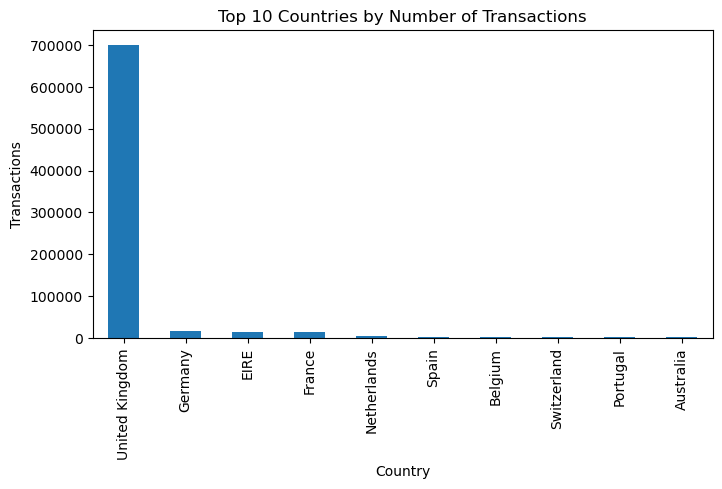

In [6]:
# Total unique countries
print("Unique Counrties: ", data["Country"].unique())

# Number of transactions per country
data["Country"].value_counts().head(10).plot(kind="bar",figsize=(8,4))
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Transactions")
# plt.xticks(rotation=45)
# plt.tight_layout()

- ### Quantity Analysis

Summary statistics: 
 count    779493.000000
mean         13.506731
std         146.540112
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64


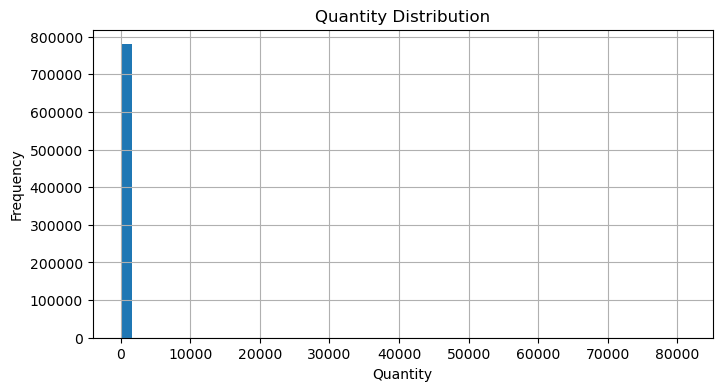

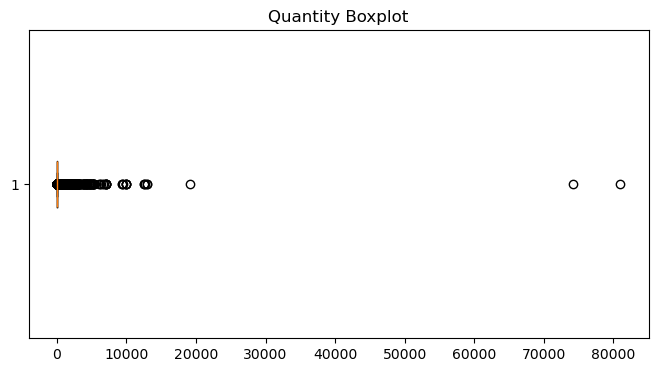

In [7]:
# Summary statistics
print("Summary statistics: \n", data["Quantity"].describe())

# histogram
plt.figure(figsize=(8,4))
data["Quantity"].hist(bins=50)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
plt.boxplot(data["Quantity"], vert=False)
plt.title("Quantity Boxplot")
plt.show()

- ### Price Analysis

Price summary statistic: 
 count    779493.000000
mean          3.218199
std          29.674861
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64


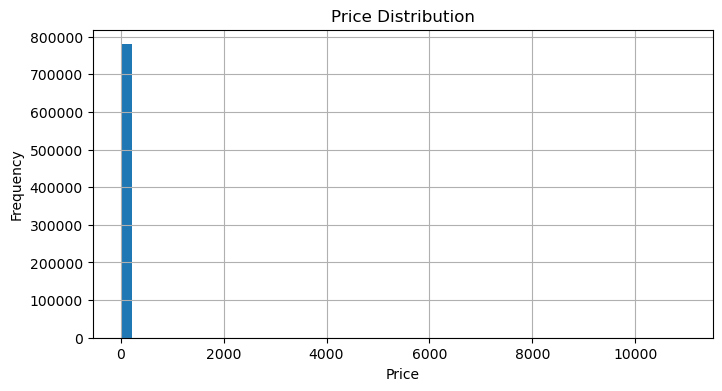

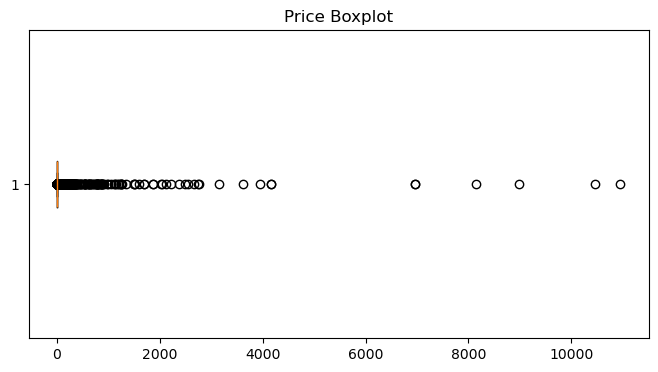

In [8]:
# Summary statistic
print("Price summary statistic: \n", data["Price"].describe())

# histogram
plt.figure(figsize=(8,4))
data["Price"].hist(bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
plt.boxplot(data["Price"], vert=False)
plt.title("Price Boxplot")
plt.show()

### Univariate Analysis Summary

#### Customer ID
- The dataset contains 5,881 unique customers.
- Customer activity is highly uneven, with a few customers making thousands of transactions while most make relatively few.

#### Country
- Transactions com from multiple countries accross Europe, Asia, North America and Oceania.
- The United Kingdom dominates the dataset by a very large margin, indicating that most customers belong to this market.

#### Quantity
- Quantity is highly right-skewed.
- Most purchases contain between 1 and 12 items.
- A small number of transactions involve extremely large purchases.

#### Price
- Product prices are also highly righ-skewed.
- Most products are inexpensive, with a median price of 1.95.
- A few have exceptionally high prices, resulting in several outliers.

#### Overall Findings
- The dataset is dominated by customers from the United Kingdom.
- Both Quantity and Price contain significant positive skewness and outliers.
- These outliers are retained because they may represent genuine high-value customers, which are important for customer segmentation.

## Bivariate Analysis

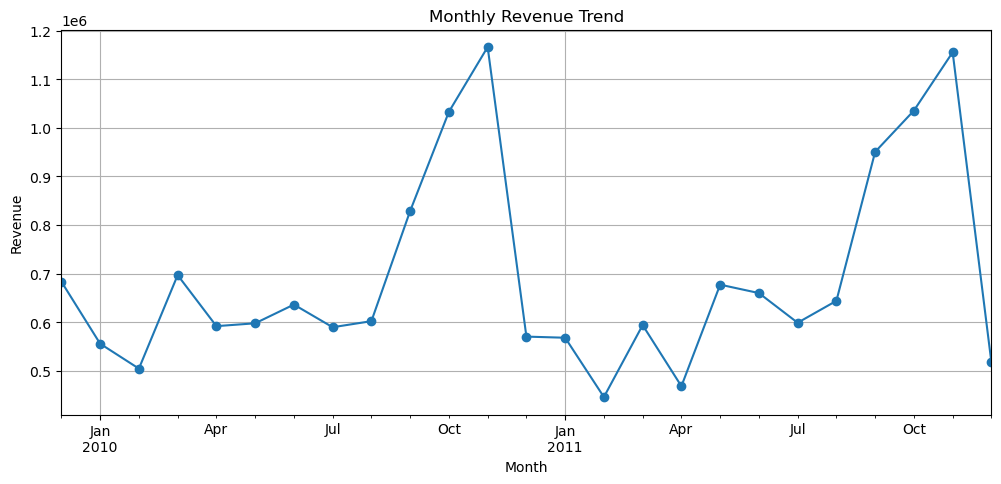

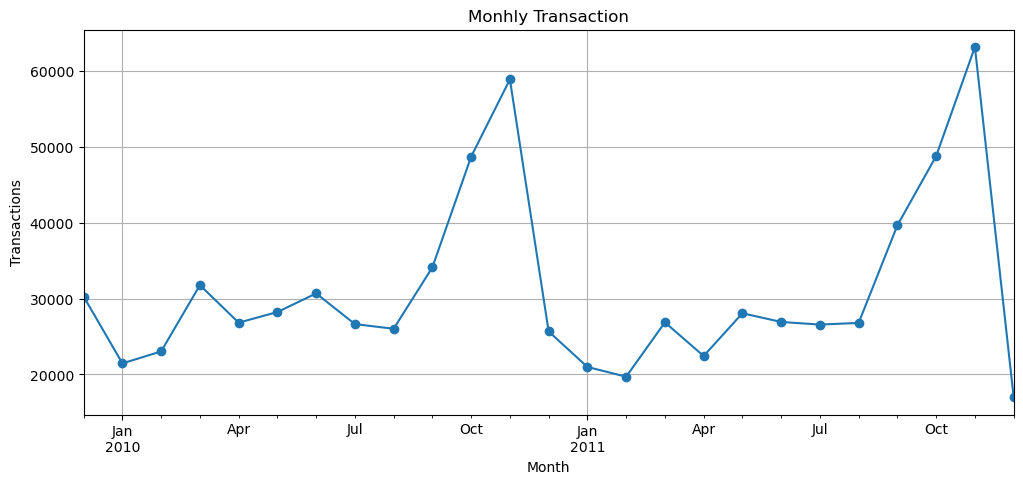

In [9]:
# Create Total Price 
data_copy = data.copy()
data_copy["TotalPrice"] = data_copy["Quantity"]*data["Price"]


# Monthly Revenue Analysis
data_copy["Month"] = data_copy["InvoiceDate"].dt.to_period("M")
monthly_revenue = data_copy.groupby("Month")["TotalPrice"].sum()

# plotting
plt.figure(figsize=(12,5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


# Monthly Transaction
print("\n")
monthly_transactions = data_copy.groupby("Month")["Invoice"].count()

# plotting
plt.figure(figsize=(12,5))
monthly_transactions.plot(kind="line", marker="o")
plt.title("Monhly Transaction")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.grid(True)
plt.show()
print("\n")

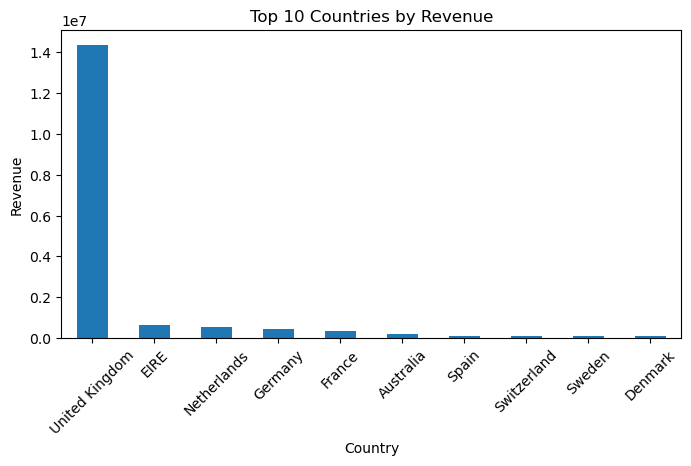

In [10]:
# Revenue by Country
country_sales = data_copy.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

# plotting
plt.figure(figsize=(8,4))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

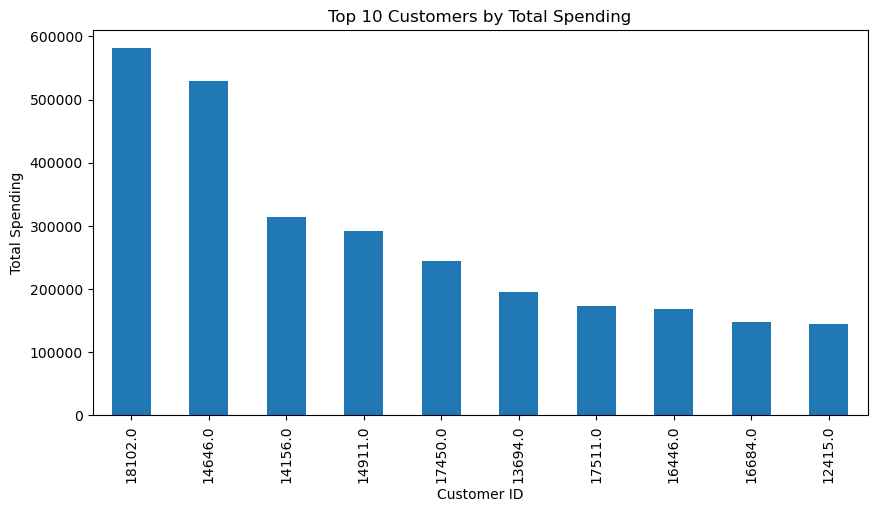

In [11]:
top_customers = data_copy.groupby("Customer ID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Total Spending")
plt.ylabel("Total Spending")
plt.show()

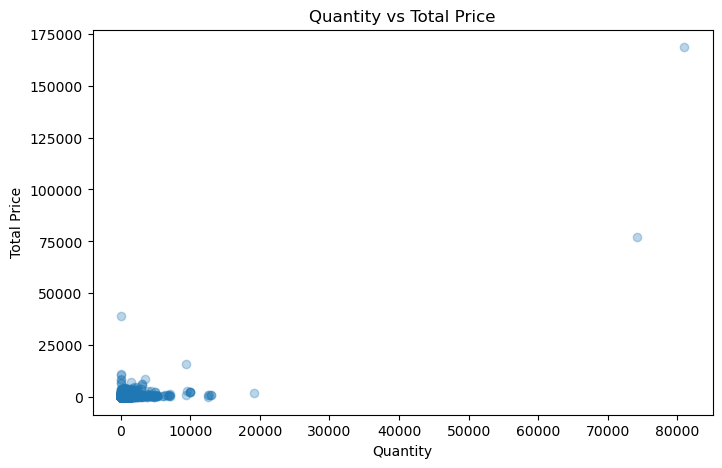

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(data_copy["Quantity"], data_copy["TotalPrice"], alpha=0.3)
plt.title("Quantity vs Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.show()

### Bivariate Analysis Summary

#### Monthly Revenue Trend
- Revenue remains relatively stable during most months but increases sharply in October and November in both years.
- The highest revenue is observed in November, indicating strong seasonal demand.
- Revenue drops significantly in December, likely because the dataset contains only a partial month.
- The business appears to have a recurring year-end sales pattern.

#### Monthly Transactions
- The number of transactions follows a pattern similar to monthly revenue.
- Transactions peak during October and November, suggesting increased customer activity.
- Lower transaction counts are observed at the beginning of the year.
- This indicates that higher revenue is mainly driven by an increase in customer purchases rather than random high-value orders.

#### Revenue by Country
- The United Kingdom contributes the overwhelming majority of total revenue.
- Revenue from other countries is comparatively much lower.
- The customer base is highly concentrated in one country.
- Country may become an important feature for understanding customer purchasing behavior.

#### Top Customers by Spending
- A small number of customers contribute a disproportionately large share of total revenue.
- The highest-spending customers spend significantly more than average customers.
- This suggests the presence of high-value (VIP) customers.
- Customer segmentation should identify these valuable customers separately.

#### Quantity vs Total Price
- There is a clear positive relationship between quantity purchased and total transaction value.
- Most transactions involve small quantities and low transaction values.
- A few extreme transactions have exceptionally high quantities and spending.
- These outliers should be investigated before clustering because distance-based algorithms such as K-Means are sensitive to extreme values.

# Featue Engineering

### Objective

The cleaned dataset contains transaction-level records. To perform customer segmentation, the data is transformed into customer-level RFM features that summarize each customer's purchasing behavior.

The following features are created:
- **TotalPrice:** Transaction value (Quantity × Price)
- **Recency:** Days since the last purchase
- **Frequency:** Number of unique purchases
- **Monetary:** Total amount spent

The feature engineering pipeline is implemented in a separate Python module to keep the project modular and reusable.

In [13]:
from feature_engineering import create_rfm_features

rfm = create_rfm_features(data)

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   4921.53
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40


### Results

The feature engineering pipeline successfully transformed transaction-level dataset into customer-level RFM features.

- Each row now represents one customer.
- TotalPrice was computed for every transaction.
- Recency, Frequency, Monetary features were created.
- This dataset is ready for preprocessing and clustering.

# Data Preprocessing

## Objective

The RFM dataset is prepared for clustering by checking: 
- Data quality
- Analyzing feature distributions
- Handling skewness and outliers 
- Scaling the features

These preprocessing steps ensure that all features contribute equally to the clustering process.

## RFM Dataset Overview

In [14]:
# rfm inspection

print(rfm.head())
print("\nShape:", rfm.shape)
print("\nData Types:")
print(rfm.dtypes)
print("\nSummary Statistics:")
print(rfm.describe())

# check for null values
print("\nNumber of missing values:")
print(rfm.isnull().sum())

# Check for duplicate customers
print("\nNumber of Duplicate customersL:")
print(rfm.duplicated().sum())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   4921.53
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40

Shape: (5881, 4)

Data Types:
Customer ID    float64
Recency          int64
Frequency        int64
Monetary       float64
dtype: object

Summary Statistics:
        Customer ID      Recency    Frequency       Monetary
count   5881.000000  5881.000000  5881.000000    5881.000000
mean   15314.674205   201.457745     6.287196    2954.302401
std     1715.429759   209.474135    13.012879   14436.758822
min    12346.000000     1.000000     1.000000       0.000000
25%    13833.000000    26.000000     1.000000     341.900000
50%    15313.000000    96.000000     3.000000     865.600000
75%    16797.000000   380.000000     7.000000    2247.720000
max    18287.000000   739.000000   398.000000  580987.040000

Number of missing valu

### Results

- The RFM dataset contains **5,881 customers** and **4 columns**.
- Each row represents a unique customer.
- The dataset contains the three engineered features: **Recency, Frequency, and Monetary**.
- No obvious data type issues were found.
- The summary statistics indicate that the features have very different value ranges, suggesting that feature scaling will be required before applying K-Means clustering.
- No missing values were found in the RFM dataset.
- No duplicated records were found.

## Analyze RFM Feature Distributions

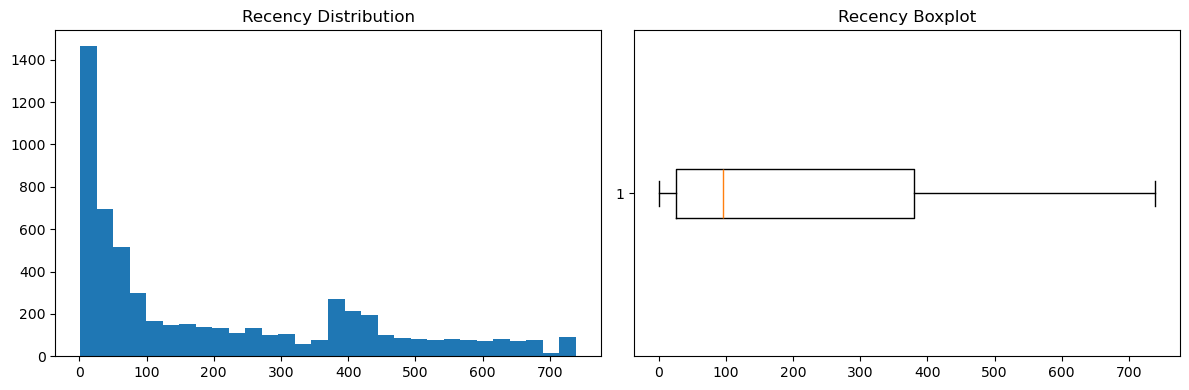

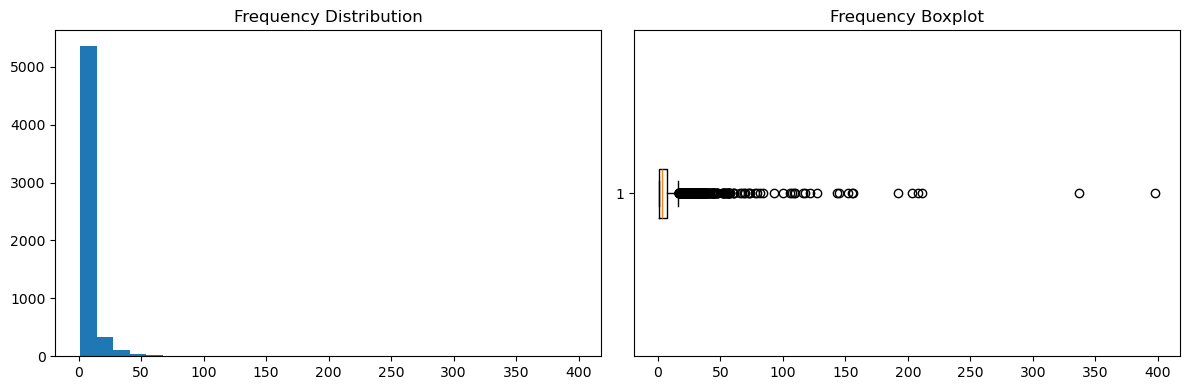

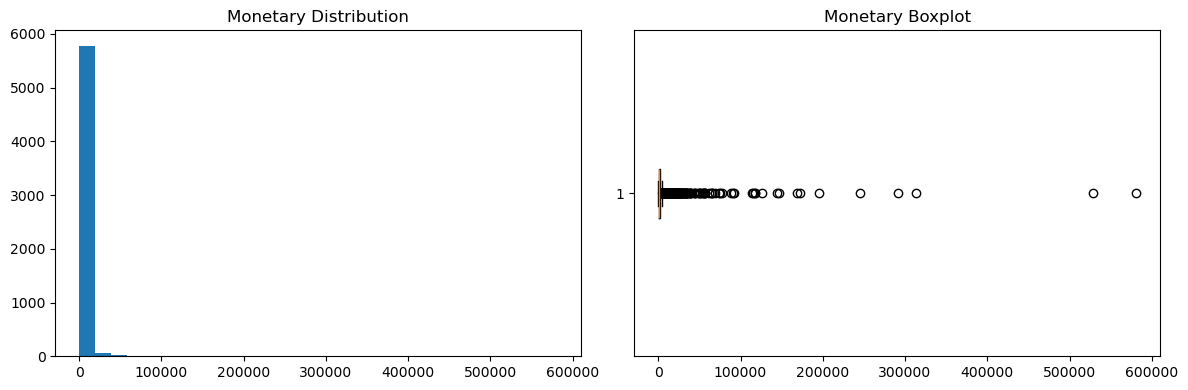

In [15]:
import matplotlib.pyplot as plt

features = ["Recency", "Frequency", "Monetary"]

for feature in features:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(rfm[feature], bins=30)
    plt.title(f"{feature} Distribution")

    plt.subplot(1,2,2)
    plt.boxplot(rfm[feature], vert=False)
    plt.title(f"{feature} Boxplot")

    plt.tight_layout()
    plt.show()

### Overall Observations

- Recency, Frequency, and Monetary are right-skewed.
- Frequency and Monetary contain many genuine outliers, representing loyal and high-value customers.
- Removing these outliers would lose important customer information.
- The three features have very different scales, so feature scaling is required before clustering.

## Balance Skewness

In [16]:
# Apply log Transformation to reduce skewness

import numpy as np

rfm_copy = rfm.copy()

rfm_copy["Recency"] = np.log1p(rfm_copy["Recency"])
rfm_copy["Frequency"] = np.log1p(rfm_copy["Frequency"])
rfm_copy["Monetary"] = np.log1p(rfm_copy["Monetary"])

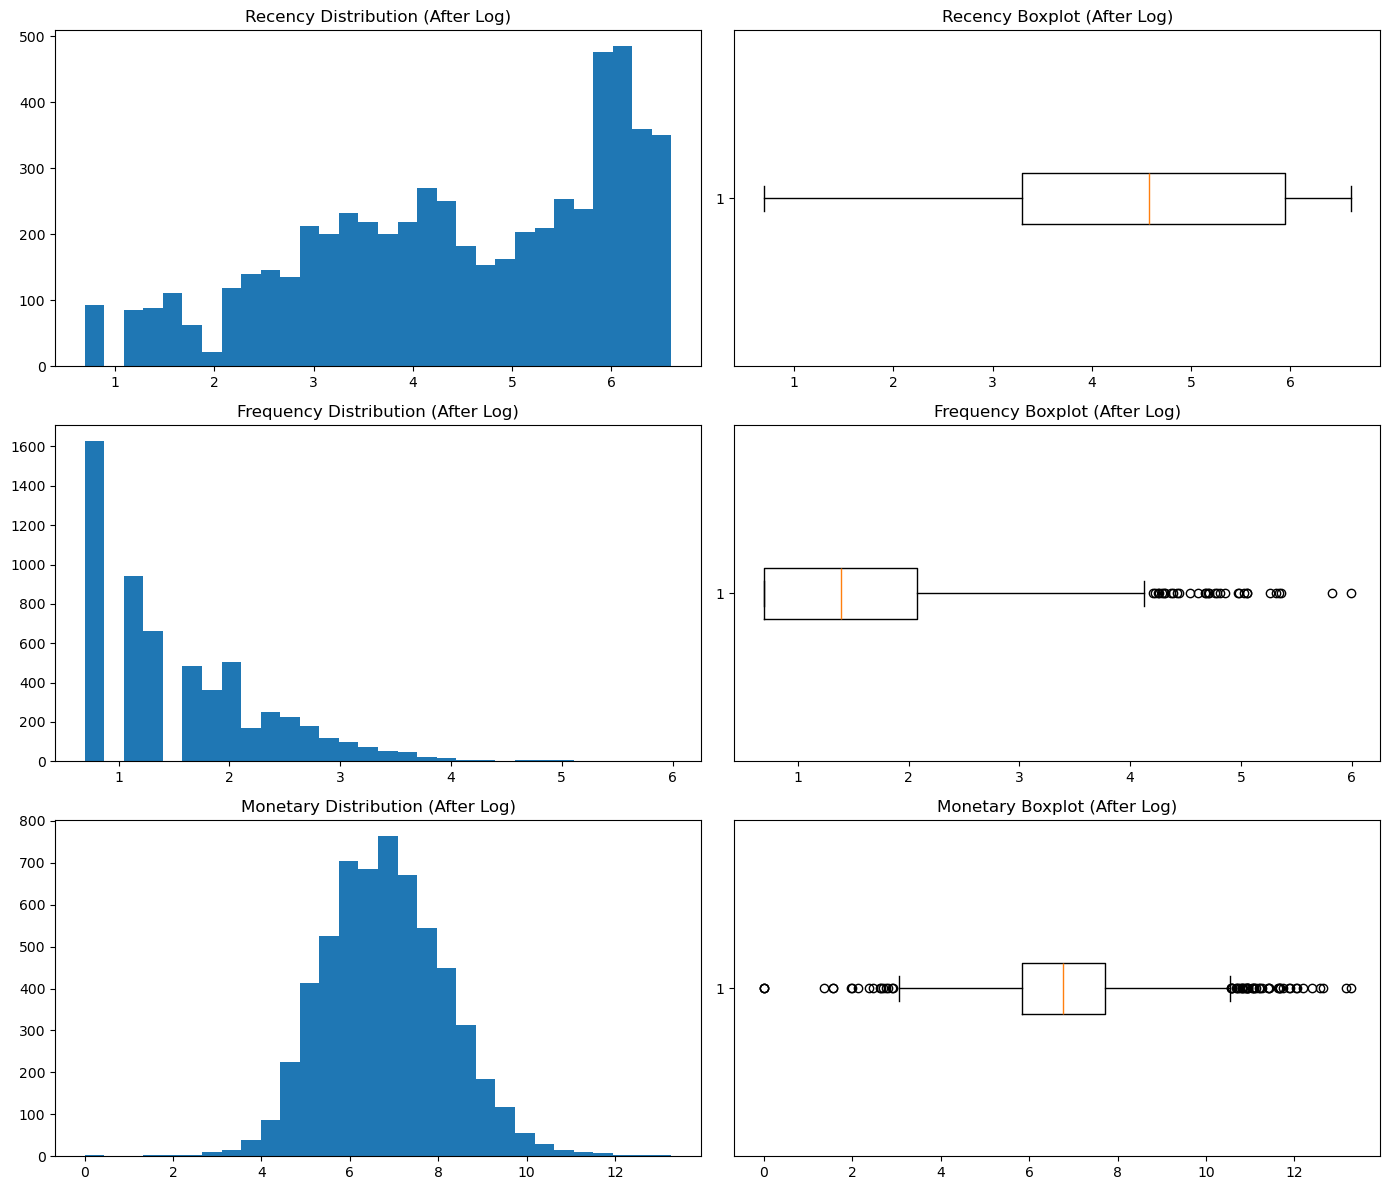

In [17]:
plt.figure(figsize=(14, 12))

# Recency
plt.subplot(3, 2, 1)
plt.hist(rfm_copy["Recency"], bins=30)
plt.title("Recency Distribution (After Log)")

plt.subplot(3, 2, 2)
plt.boxplot(rfm_copy["Recency"], vert=False)
plt.title("Recency Boxplot (After Log)")

# Frequency
plt.subplot(3, 2, 3)
plt.hist(rfm_copy["Frequency"], bins=30)
plt.title("Frequency Distribution (After Log)")

plt.subplot(3, 2, 4)
plt.boxplot(rfm_copy["Frequency"], vert=False)
plt.title("Frequency Boxplot (After Log)")

# Monetary
plt.subplot(3, 2, 5)
plt.hist(rfm_copy["Monetary"], bins=30)
plt.title("Monetary Distribution (After Log)")

plt.subplot(3, 2, 6)
plt.boxplot(rfm_copy["Monetary"], vert=False)
plt.title("Monetary Boxplot (After Log)")

plt.tight_layout()
plt.show()

### Results
- Log transformation successfully reduced the skewness of all RFM features.
- Extreme values were compressed while preserving the relative ordering of customers.
- The Monetary feature is now approximately normally distributed.
- Frequency still contains a few high-value customers, which are likely genuine observations.
- The transformed RFM dataset is suitable for feature scaling.

## Log Transformation and Scaling

In [18]:
from preprocessing import preprocess_data
rfm_scaled = preprocess_data(rfm)

# Optimal "K" value

## Elbow Method

### Objective
Determine the optimal number of Customer segments using the elbow Method and Silhoutte Score before applying K-Means clustering

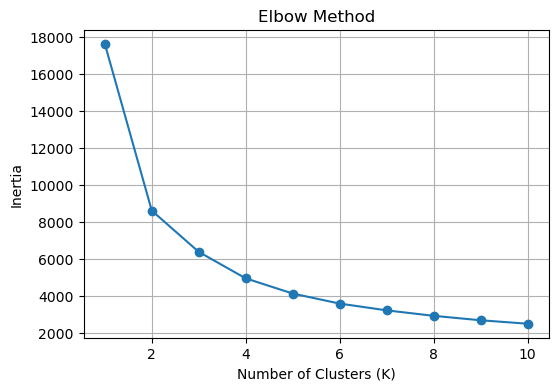

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    kmeans =KMeans(
    n_clusters=k,
    random_state=42,
    n_init = 10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

### Result

- The inertia decreases rapidly until K = 4.
- After K = 4, the reduction in inertia becomes gradual.
- This suggests that 4 clusters may provide a good balance between cluster compactness and model complexity.
- The final value of K will be confirmed using the Silhouette Score.

## Silhoutte Score

### Objective

Evaluate the quality of clustering for different values of K and the number of clusters that provides the best separation.

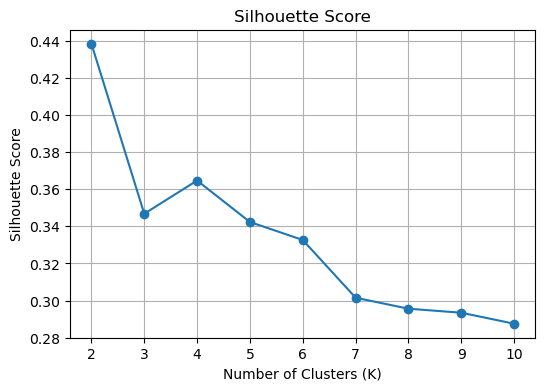

In [20]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid(True)
plt.show()

### Result

- The Elbow Method suggests an optimal number of clusters around K = 4, where the decrease in inertia begins to slow down.
- The Silhouette Score is highest at K = 2, but K = 4 also provides a good clustering quality while offering more meaningful customer segments.
- Considering both methods, K = 4 is selected as the optimal number of clusters for customer segmentation.
- The next step is to train the final K-Means model using 4 clusters and assign a cluster label to each customer.

# Model

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans( n_clusters=4, random_state=42, n_init=10)

In [22]:
rfm_original = create_rfm_features(data)

rfm_original["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm_original.head())

# Cluster Distribution
rfm_original["Cluster"].value_counts().sort_index()

   Customer ID  Recency  Frequency  Monetary  Cluster
0      12346.0      326         12  77556.46        3
1      12347.0        2          8   4921.53        3
2      12348.0       75          5   2019.40        0
3      12349.0       19          4   4428.69        2
4      12350.0      310          1    334.40        1


Cluster
0    1463
1    1979
2    1251
3    1188
Name: count, dtype: int64

### Result

- The final K-Means model was successfully trained using 4 clusters.
- Each customer was assigned to one of the four clusters.
- The dataset now includes a new Cluster column representing the segment assigned to each customer.
- The clustered dataset is ready for cluster profiling and business interpretation.

# Cluster Profiling

In [23]:
# Characteristics of clusters by computing the average Recency, Frequency, Monetary values
cluster_profile = rfm_original.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean() 

# round the values for readability
cluster_profile = cluster_profile.round(2)
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,228.07,5.09,1963.46
1,395.66,1.38,318.35
2,28.36,3.04,854.34
3,27.45,19.35,10776.86


In [24]:
# Number of customers in each cluster
rfm_original.groupby("Cluster").size()

Cluster
0    1463
1    1979
2    1251
3    1188
dtype: int64

### Result

- Four distinct customer clusters were identified based on their average Recency, Frequency, and Monetary (RFM) values.
- Each cluster exhibits different purchasing behavior and customer characteristics.

In [25]:
# Cluster labeling

cluster_names = {
    0: "At Risk Customers",
    1: "Lost Customers",
    2: "Active Customers",
    3: "VIP Customers"
}

rfm_original["Customer Segment"] = rfm_original["Cluster"].map(cluster_names)

rfm_original.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Customer Segment
0,12346.0,326,12,77556.46,3,VIP Customers
1,12347.0,2,8,4921.53,3,VIP Customers
2,12348.0,75,5,2019.40,0,At Risk Customers
3,12349.0,19,4,4428.69,2,Active Customers
4,12350.0,310,1,334.40,1,Lost Customers


# Result

- Customers were successfully segmented into four meaningful business groups using K-Means clustering.
- Cluster IDs were mapped to descriptive customer segments based on Recency, Frequency, and Monetary (RFM) behavior.
- The identified segments are VIP Customers, Active Customers, At Risk Customers, and Lost Customers.
- These segments can help businesses design targeted marketing campaigns, customer retention strategies, and personalized offers.

# Business Recommendation

| **Segment** | **Recommendation** |
| ----------- | ------------------ |
| VIP Customers | Loyalty rewards, premium offers |
| Active Customers | Cross-sell and upsell |
| At Risk Customers | Retention campaigns and discounts |
| Lost Customers | Win-back email and special offers |